In [63]:
# Inspect Kaggle input folders to find the real dataset path

from pathlib import Path

input_root = Path("/kaggle/input")

for path in input_root.rglob("*"):
    if path.is_dir():
        print(path)

/kaggle/input/datasets
/kaggle/input/datasets/wanemdehan
/kaggle/input/datasets/wanemdehan/traffic-sign-2
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Test
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train/DIrection
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train/Cautions
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train/SpeedLimit
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train/No Entry
/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2/Train/Crossings


In [2]:
import os
import time
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

2026-05-10 00:59:12.597682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778374753.011285      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778374753.112506      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778374754.107715      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778374754.107756      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778374754.107759      57 computation_placer.cc:177] computation placer alr

In [25]:
# Automatically find the Kaggle dataset folder that contains Train and Test

from pathlib import Path

input_root = Path("/kaggle/input")
dataset_path = None

for path in input_root.rglob("*"):
    if path.is_dir() and (path / "Train").exists() and (path / "Test").exists():
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Could not find a dataset folder containing Train and Test.")

train_dir = dataset_path / "Train"
test_dir = dataset_path / "Test"

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

Dataset path: /kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2
Dataset exists: True
Train exists: True
Test exists: True


In [10]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
Available GPU devices: []


# 2.5.1 Dataset Understanding, Preprocessing, and Augmentation

# Dataset Understanding and Preprocessing Summary

- The dataset contains road images of traffic signs. The task is to classify each image into one of five traffic sign categories: Cautions, Crossings, Direction, No Entry, and SpeedLimit.

- The original training folder contained 16,100 images. During data cleaning, 35 corrupted files were detected and removed. After cleaning, 16,065 valid training images were used.

- The original class distribution was not balanced. SpeedLimit was the largest class with 6,688 images, while Cautions was the smallest class with 1,678 images.

- After removing corrupted files, the cleaned class distribution became:
  - SpeedLimit: 6,681 images
  - Direction: 2,961 images
  - No Entry: 2,931 images
  - Crossings: 1,821 images
  - Cautions: 1,671 images

- The cleaned dataset was split into training and validation sets using an 80:20 stratified split. This gave 12,852 training images and 3,213 validation images.

- Stratified splitting was used because the dataset was imbalanced. This helped keep the class proportions similar in both training and validation sets.

- Images were resized to 96 × 96 pixels for the custom CNN models. Pixel values were normalized by scaling them to the range 0 to 1.

- For transfer learning with MobileNetV2, images were resized to 224 × 224 pixels and processed using the MobileNetV2 preprocessing function.

- ImageDataGenerator was used to load images from dataframes and apply preprocessing.

- For training, data augmentation was applied using small rotations, width and height shifts, zooming, and brightness changes.

- Horizontal flipping was not used because flipping traffic signs can change their meaning.

- For validation, only resizing and normalization were applied. No augmentation was used on the validation set.

- Sample augmented images were visualized to check that the augmentation pipeline worked correctly and did not distort the traffic signs too much.

## 2. Dataset Loading and Folder Inspection

In [17]:
# Locate the dataset folder inside Kaggle input storage

from pathlib import Path

dataset_path = Path("/kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2")

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

Dataset path: /kaggle/input/datasets/wanemdehan/traffic-sign-2/Traffic_Sign_-2
Dataset exists: True


In [12]:
# Inspect the immediate folder structure of the dataset

if dataset_path is not None:
    class_folders = sorted([folder for folder in dataset_path.iterdir() if folder.is_dir()])
    print("Detected class folders:")
    for folder in class_folders:
        print("-", folder.name)

Detected class folders:
- Test
- Train


## 3. Split Inspection

In [22]:
# Set dataset paths

from pathlib import Path

# Use your real Kaggle dataset path here if different
dataset_path = Path("/kaggle/input/traffic-sign-2/Traffic_Sign_-2")

train_dir = dataset_path / "Train"
test_dir = dataset_path / "Test"

print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())
print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

Dataset path: /kaggle/input/traffic-sign-2/Traffic_Sign_-2
Dataset exists: False
Train exists: False
Test exists: False


In [26]:
# List the class folders inside each split directory
from pathlib import Path
def list_class_folders(split_dir: Path) -> list[Path]:
    """
    Return a sorted list of class folders inside a dataset split directory.

    Parameters:
        split_dir (Path): Path to a dataset split such as Train or Test.

    Returns:
        list[Path]: Sorted list of class folder paths.
    """
    return sorted([folder for folder in split_dir.iterdir() if folder.is_dir()])


train_class_folders = list_class_folders(train_dir)
test_class_folders = list_class_folders(test_dir)

print("Train class folders:")
for folder in train_class_folders:
    print("-", folder.name)

print("\nTest class folders:")
for folder in test_class_folders:
    print("-", folder.name)

Train class folders:
- Cautions
- Crossings
- DIrection
- No Entry
- SpeedLimit

Test class folders:


In [27]:
# Compare class names across the train and test splits

train_class_names = [folder.name for folder in train_class_folders]
test_class_names = [folder.name for folder in test_class_folders]

print("Classes match across splits:", train_class_names == test_class_names)
print("Number of train classes:", len(train_class_names))
print("Number of test classes:", len(test_class_names))

Classes match across splits: False
Number of train classes: 5
Number of test classes: 0


## 4. Test Split Inspection

In [28]:
# Inspect the immediate contents of the test directory

test_items = sorted(list(test_dir.iterdir()))

print(f"Number of items inside the Test directory: {len(test_items)}")
print("\nFirst 20 items:")

for item in test_items[:20]:
    item_type = "Folder" if item.is_dir() else "File"
    print(f"- {item.name} ({item_type})")

Number of items inside the Test directory: 10

First 20 items:
- 00004_00002_00011.png (File)
- 00008_00013_00018.png (File)
- 00014_00000_00002.png (File)
- 00015_00002_00026.png (File)
- 00021_00000_00000.png (File)
- 00021_00000_00001.png (File)
- 00027_00000_00002.png (File)
- 00027_00000_00003.png (File)
- 00036_00000_00001.png (File)
- 00036_00000_00002.png (File)


In [29]:
# Count how many files and folders are directly inside the test directory

num_test_files = sum(1 for item in test_items if item.is_file())
num_test_folders = sum(1 for item in test_items if item.is_dir())

print("Number of files in Test:", num_test_files)
print("Number of folders in Test:", num_test_folders)

Number of files in Test: 10
Number of folders in Test: 0


In [31]:
# Inspect nested folders if the test directory contains subfolders

if num_test_folders > 0:
    print("Nested folder contents inside Test:\n")

    for folder in [item for item in test_items if item.is_dir()]:
        nested_items = sorted(list(folder.iterdir()))
        print(f"{folder.name}: {len(nested_items)} items")

        for nested_item in nested_items[:10]:
            nested_type = "Folder" if nested_item.is_dir() else "File"
            print(f"  - {nested_item.name} ({nested_type})")

        print()

## 5. Train Split Class Distribution

In [32]:
# Count image files in each training class folder and normalise inconsistent class names

def normalise_class_name(class_name: str) -> str:
    """
    Normalise inconsistent class names found in the dataset.

    Parameters:
        class_name (str): Original class folder name.

    Returns:
        str: Cleaned class name.
    """
    if class_name == "DIrection":
        return "Direction"
    return class_name


def count_image_files_by_class(split_dir: Path) -> dict:
    """
    Count image files inside each class folder of a dataset split.

    Parameters:
        split_dir (Path): Path to the dataset split directory.

    Returns:
        dict: A dictionary mapping class names to image counts.
    """
    valid_suffixes = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}
    class_counts = {}

    for class_folder in sorted([folder for folder in split_dir.iterdir() if folder.is_dir()]):
        class_name = normalise_class_name(class_folder.name)
        image_count = sum(
            1
            for file_path in class_folder.iterdir()
            if file_path.is_file() and file_path.suffix.lower() in valid_suffixes
        )
        class_counts[class_name] = image_count

    return class_counts


train_class_counts = count_image_files_by_class(train_dir)

print("Training image count by class:")
for class_name, count in train_class_counts.items():
    print(f"- {class_name}: {count}")

Training image count by class:
- Cautions: 1678
- Crossings: 1828
- Direction: 2968
- No Entry: 2938
- SpeedLimit: 6688


In [27]:
# Summarise the total number of training images and the number of detected classes

total_train_images = sum(train_class_counts.values())
num_train_classes = len(train_class_counts)

print("Total training images:", total_train_images)
print("Number of training classes:", num_train_classes)

Total training images: 16100
Number of training classes: 5


## 6. Corrupted File Detection

In [40]:
# Detect unreadable image files in the training split

from PIL import Image, UnidentifiedImageError

def find_corrupted_images(split_dir: Path) -> list[Path]:
    """
    Identify corrupted or unreadable image files inside a dataset split.

    Parameters:
        split_dir (Path): Path to the dataset split directory.

    Returns:
        list[Path]: A list of corrupted image file paths.
    """
    valid_suffixes = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}
    corrupted_files = []

    for class_folder in sorted([folder for folder in split_dir.iterdir() if folder.is_dir()]):
        for file_path in class_folder.iterdir():
            if file_path.is_file() and file_path.suffix.lower() in valid_suffixes:
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (UnidentifiedImageError, OSError, ValueError):
                    corrupted_files.append(file_path)

    return corrupted_files


corrupted_train_files = find_corrupted_images(train_dir)

print("Number of corrupted files in Train:", len(corrupted_train_files))

Number of corrupted files in Train: 35


## 7. Create a Clean Training Dataset

In [41]:
# Create a cleaned local copy of the training dataset for faster and safer model development

import shutil

clean_root_dir = Path("/content/traffic_sign_cleaned")
clean_train_dir = clean_root_dir / "Train"

clean_train_dir.mkdir(parents=True, exist_ok=True)

print("Clean training directory:", clean_train_dir)

Clean training directory: /content/traffic_sign_cleaned/Train


In [42]:
# Copy only valid training images into the cleaned dataset and normalise class folder names

def build_clean_train_split(source_dir: Path, target_dir: Path, corrupted_files: list[Path]) -> dict:
    """
    Build a cleaned training split by excluding corrupted files and normalising class names.

    Parameters:
        source_dir (Path): Path to the original training directory.
        target_dir (Path): Path where the cleaned training directory should be created.
        corrupted_files (list[Path]): List of corrupted image paths to exclude.

    Returns:
        dict: A dictionary mapping cleaned class names to the number of copied valid images.
    """
    corrupted_set = {file_path.resolve() for file_path in corrupted_files}
    valid_suffixes = {".png", ".jpg", ".jpeg", ".bmp", ".gif"}
    copied_counts = {}

    for class_folder in sorted([folder for folder in source_dir.iterdir() if folder.is_dir()]):
        clean_class_name = normalise_class_name(class_folder.name)
        target_class_dir = target_dir / clean_class_name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        copied_count = 0

        for file_path in class_folder.iterdir():
            if file_path.is_file() and file_path.suffix.lower() in valid_suffixes:
                if file_path.resolve() not in corrupted_set:
                    shutil.copy2(file_path, target_class_dir / file_path.name)
                    copied_count += 1

        copied_counts[clean_class_name] = copied_count

    return copied_counts


clean_train_class_counts = build_clean_train_split(train_dir, clean_train_dir, corrupted_train_files)

print("Valid image count by class in the cleaned training split:")
for class_name, count in clean_train_class_counts.items():
    print(f"- {class_name}: {count}")

Valid image count by class in the cleaned training split:
- Cautions: 1671
- Crossings: 1821
- Direction: 2961
- No Entry: 2931
- SpeedLimit: 6681


In [45]:
# Summarise the cleaned training split after corrupted-file removal

total_clean_train_images = sum(clean_train_class_counts.values())

try:
    total_train_images
except NameError:
    total_train_images = total_clean_train_images + len(corrupted_train_files)

print("Total valid training images after cleaning:", total_clean_train_images)
print("Removed corrupted files:", total_train_images - total_clean_train_images)

Total valid training images after cleaning: 16065
Removed corrupted files: 35


## 8. Cleaned Class Distribution Analysis

In [30]:
# Summarise the cleaned class distribution with counts and percentages
import pandas as pd
class_distribution_df = pd.DataFrame(
    {
        "Class": list(clean_train_class_counts.keys()),
        "Image_Count": list(clean_train_class_counts.values()),
    }
)

class_distribution_df["Percentage"] = (
    class_distribution_df["Image_Count"] / class_distribution_df["Image_Count"].sum() * 100
).round(2)

class_distribution_df = class_distribution_df.sort_values(
    by="Image_Count", ascending=False
).reset_index(drop=True)

print(class_distribution_df)

        Class  Image_Count  Percentage
0  SpeedLimit         6681       41.59
1   Direction         2961       18.43
2    No Entry         2931       18.24
3   Crossings         1821       11.34
4    Cautions         1671       10.40


In [31]:
# Compute the imbalance ratio between the largest and smallest classes

largest_class_count = class_distribution_df["Image_Count"].max()
smallest_class_count = class_distribution_df["Image_Count"].min()
imbalance_ratio = round(largest_class_count / smallest_class_count, 2)

print("Largest class count:", largest_class_count)
print("Smallest class count:", smallest_class_count)
print("Imbalance ratio (largest-to-smallest):", imbalance_ratio)

Largest class count: 6681
Smallest class count: 1671
Imbalance ratio (largest-to-smallest): 4.0


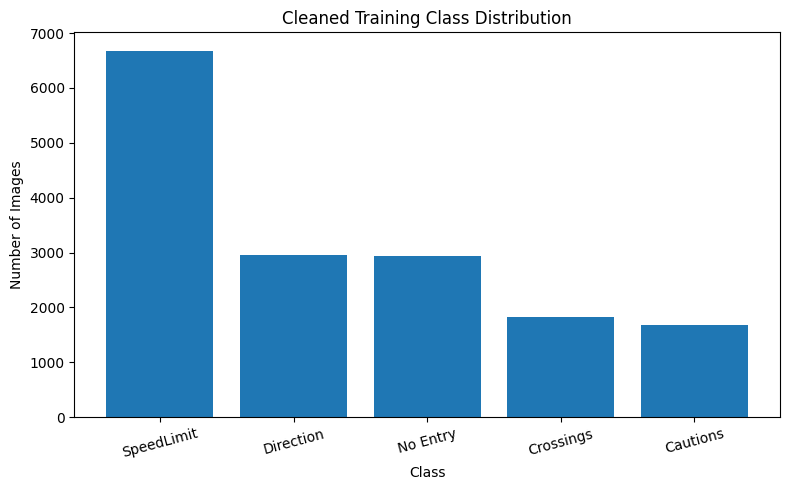

In [33]:
# Plot the cleaned class distribution for visual inspection
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(class_distribution_df["Class"], class_distribution_df["Image_Count"])
plt.title("Cleaned Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Train, Validation, and Test Split

In [34]:
# Create a dataframe of cleaned image paths and labels for stratified train-validation splitting

image_records = []

for class_folder in sorted([folder for folder in clean_train_dir.iterdir() if folder.is_dir()]):
    class_name = class_folder.name

    for file_path in class_folder.iterdir():
        if file_path.is_file():
            image_records.append(
                {
                    "filepath": str(file_path),
                    "label": class_name
                }
            )

image_df = pd.DataFrame(image_records)

print("Total cleaned image records:", len(image_df))
print(image_df.head())

Total cleaned image records: 16065
                                            filepath     label
0  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
1  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
2  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
3  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
4  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions


In [37]:
# Initial stratified split used to check possible group overlap
from sklearn.model_selection import train_test_split

initial_train_df, initial_val_df = train_test_split(
    image_df,
    test_size=0.2,
    stratify=image_df["label"],
    random_state=42
)

print("Initial training samples:", len(initial_train_df))
print("Initial validation samples:", len(initial_val_df))

Initial training samples: 12852
Initial validation samples: 3213


In [38]:
# Check for similar image groups in the initial train and validation split

from pathlib import Path

def make_group_id_fast(path_series, label_series):
    """
    Create group IDs from image file paths and labels.

    Parameters:
    path_series : pandas.Series
        Series containing image file paths.
    label_series : pandas.Series
        Series containing class labels.

    Returns:
    pandas.Series
        Group IDs used to check whether related images appear in both splits.
    """
    filenames = path_series.apply(lambda p: Path(p).stem)

    groups = filenames.apply(
        lambda name: "_".join(name.split("_")[:2]) if len(name.split("_")) >= 3 else name
    )

    return label_series + "_" + groups


initial_train_df["group_id"] = make_group_id_fast(
    initial_train_df["filepath"],
    initial_train_df["label"]
)

initial_val_df["group_id"] = make_group_id_fast(
    initial_val_df["filepath"],
    initial_val_df["label"]
)

train_groups = set(initial_train_df["group_id"])
val_groups = set(initial_val_df["group_id"])

overlap_groups = train_groups.intersection(val_groups)

print("Unique train groups:", len(train_groups))
print("Unique validation groups:", len(val_groups))
print("Overlapping groups:", len(overlap_groups))

print("\nSample overlapping groups:")
print(list(overlap_groups)[:10])

Unique train groups: 537
Unique validation groups: 537
Overlapping groups: 537

Sample overlapping groups:
['Cautions_00030_00003', 'SpeedLimit_00004_00039', 'No Entry_00016_00006', 'SpeedLimit_00008_00005', 'SpeedLimit_00004_00000', 'Direction_00038_00039', 'Direction_00038_00030', 'SpeedLimit_00008_00021', 'Cautions_00022_00001', 'SpeedLimit_00005_00056']


### Train-validation group overlap check

- I checked if the same image groups were in both training and validation sets.
- The result showed **537 overlapping groups**.
- This means some similar images are in both sets.
- This can make the validation accuracy look too high.
- So, the split needs to be fixed.
- A group-based split will keep similar images together in only one set.

In [39]:
# Create final train, validation, and test splits using image groups

from sklearn.model_selection import GroupShuffleSplit
from pathlib import Path

def make_group_id(filepath, label):
    """
    Create a group ID from an image filepath and its class label.

    Parameters:
    filepath : str
        Full path of the image file.
    label : str
        Class label of the image.

    Returns:
    str
        A group ID made from the class label and the first two parts of the filename.
        This is used to keep related images in the same split.
    """
    filename = Path(filepath).stem
    parts = filename.split("_")

    # Example: 00004_00002_00011 -> group is 00004_00002
    if len(parts) >= 3:
        group = "_".join(parts[:2])
    else:
        group = filename

    return f"{label}_{group}"


# Add group ID to the full dataframe
image_df["group_id"] = image_df.apply(
    lambda row: make_group_id(row["filepath"], row["label"]),
    axis=1
)

# First split: 70% training and 30% temporary data
first_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_index, temp_index = next(
    first_split.split(
        image_df,
        groups=image_df["group_id"]
    )
)

train_df = image_df.iloc[train_index].reset_index(drop=True)
temp_df = image_df.iloc[temp_index].reset_index(drop=True)

# Second split: split temporary data equally into validation and test
second_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_index, test_index = next(
    second_split.split(
        temp_df,
        groups=temp_df["group_id"]
    )
)

val_df = temp_df.iloc[val_index].reset_index(drop=True)
test_df = temp_df.iloc[test_index].reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

# Check that image groups are not shared between splits
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

print("Train-validation group overlap:", len(train_groups.intersection(val_groups)))
print("Train-test group overlap:", len(train_groups.intersection(test_groups)))
print("Validation-test group overlap:", len(val_groups.intersection(test_groups)))

Training samples: 11221
Validation samples: 2424
Test samples: 2420
Train-validation group overlap: 0
Train-test group overlap: 0
Validation-test group overlap: 0


In [40]:
# Compare class distributions in the training, validation, and test splits

print("Training split class distribution:")
print(train_df["label"].value_counts())

print("\nValidation split class distribution:")
print(val_df["label"].value_counts())

print("\nTest split class distribution:")
print(test_df["label"].value_counts())

Training split class distribution:
label
SpeedLimit    4613
No Entry      2183
Direction     2096
Crossings     1194
Cautions      1135
Name: count, dtype: int64

Validation split class distribution:
label
SpeedLimit    1079
Direction      477
No Entry       419
Cautions       240
Crossings      209
Name: count, dtype: int64

Test split class distribution:
label
SpeedLimit    989
Crossings     418
Direction     388
No Entry      329
Cautions      296
Name: count, dtype: int64


## 10. Image Size Inspection and Sample Visualisation

In [41]:
# Measure image width and height across the cleaned dataset

image_sizes = []

for file_path in image_df["filepath"]:
    with Image.open(file_path) as img:
        width, height = img.size
        image_sizes.append((width, height))

size_df = pd.DataFrame(image_sizes, columns=["width", "height"])

print("Average width:", round(size_df["width"].mean(), 2))
print("Average height:", round(size_df["height"].mean(), 2))
print("Minimum width:", size_df["width"].min())
print("Maximum width:", size_df["width"].max())
print("Minimum height:", size_df["height"].min())
print("Maximum height:", size_df["height"].max())

Average width: 48.52
Average height: 48.6
Minimum width: 25
Maximum width: 226
Minimum height: 25
Maximum height: 219


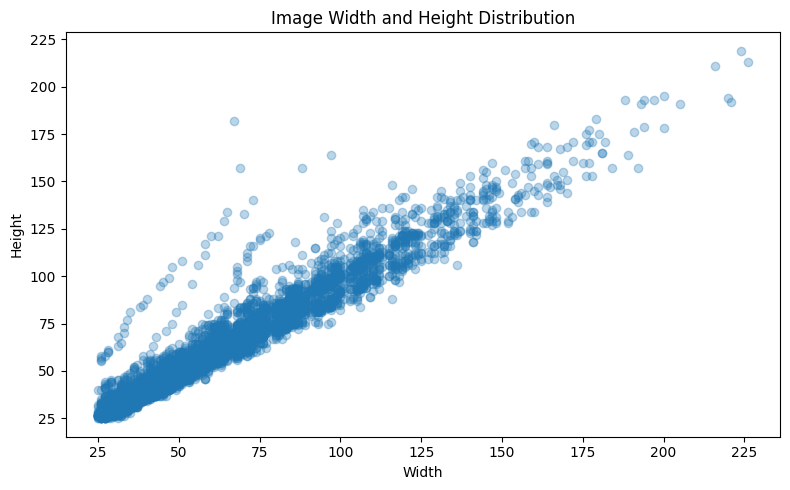

In [42]:
# Plot the distribution of image widths and heights

plt.figure(figsize=(8, 5))
plt.scatter(size_df["width"], size_df["height"], alpha=0.3)
plt.title("Image Width and Height Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

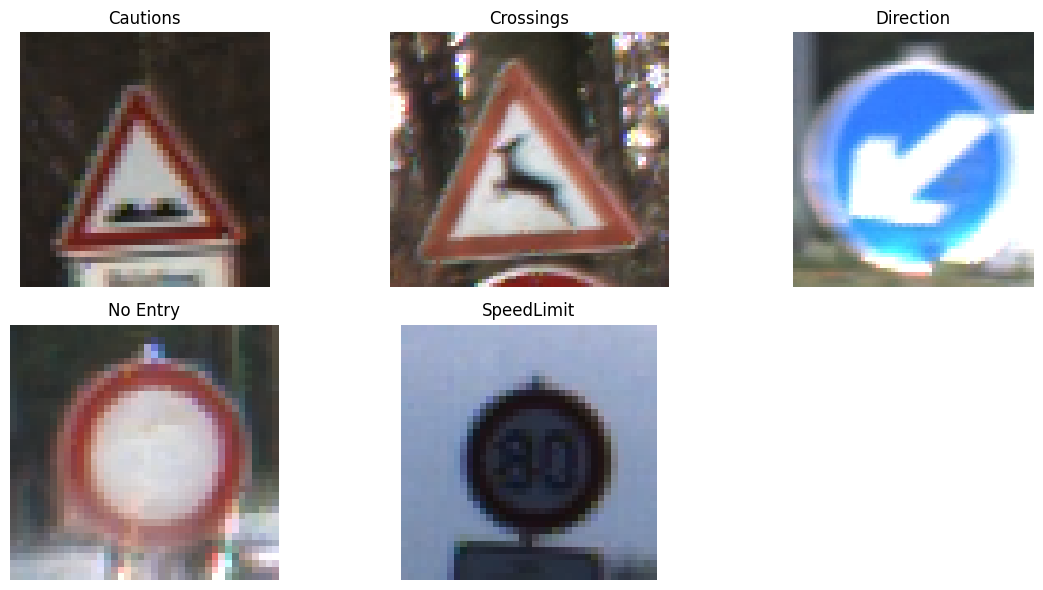

In [43]:
# Display sample images from different classes for visual inspection

sample_images = []

for class_name in sorted(train_df["label"].unique()):
    sample_path = train_df[train_df["label"] == class_name]["filepath"].iloc[0]
    sample_images.append((class_name, sample_path))

plt.figure(figsize=(12, 6))

for index, (class_name, sample_path) in enumerate(sample_images, start=1):
    with Image.open(sample_path) as img:
        plt.subplot(2, 3, index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

## 11. Preprocessing Configuration

In [50]:
# Define image preprocessing settings for model development

image_size = (96, 96)
batch_size = 32
random_seed = 42

print("Target image size:", image_size)
print("Batch size:", batch_size)
print("Random seed:", random_seed)

Target image size: (96, 96)
Batch size: 32
Random seed: 42


In [49]:
# Configure data augmentation for the training set and basic preprocessing for the validation and test sets

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.8, 1.2)
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [51]:
# Create training, validation, and test generators from the dataframe splits

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

test_generator = val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=image_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

Found 11221 validated image filenames belonging to 5 classes.
Found 2424 validated image filenames belonging to 5 classes.
Found 2420 validated image filenames belonging to 5 classes.


In [52]:
# Inspect the class index mapping used by the generators

print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'Cautions': 0, 'Crossings': 1, 'Direction': 2, 'No Entry': 3, 'SpeedLimit': 4}


## 12. Augmented Sample Visualisation

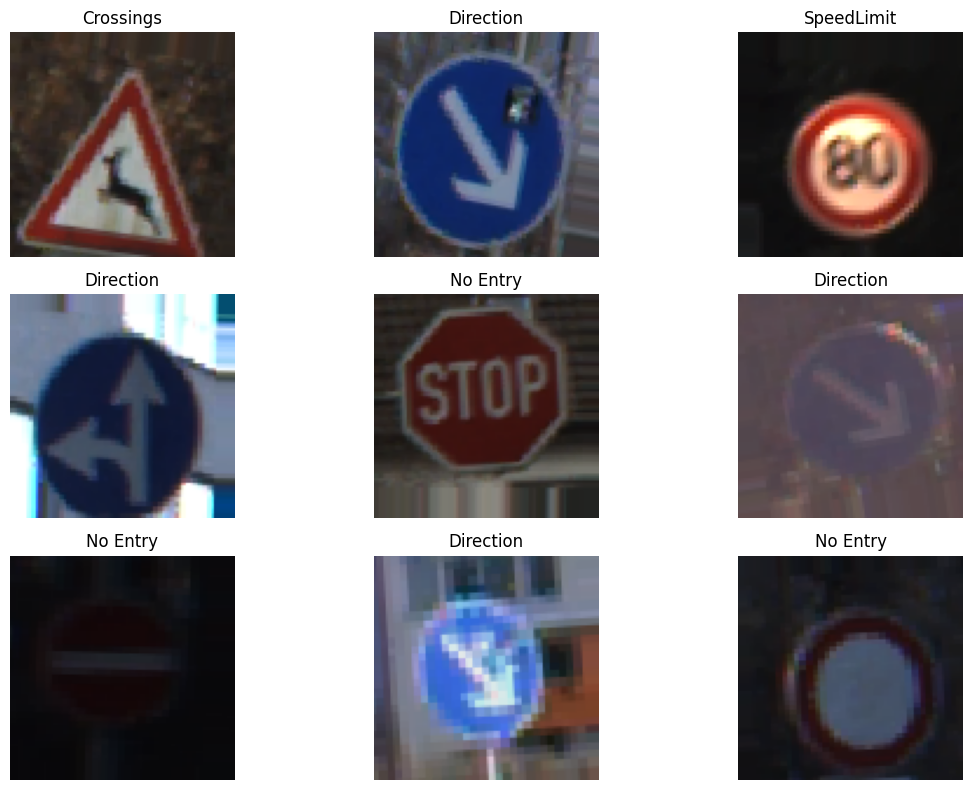

In [54]:
# Display a batch of augmented training images to verify the preprocessing pipeline
import numpy as np

augmented_images, augmented_labels = next(train_generator)

class_names = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)
    plt.imshow(augmented_images[index])
    plt.title(class_names[np.argmax(augmented_labels[index])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2.5.2 Design, Train, and Evaluate a Baseline Model

## 13. Baseline CNN Model

In [56]:
# Build the baseline CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

baseline_model = Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    layers.Dense(5, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,411,781 (13.01 MB)

 Trainable params: 3,411,781 (13.01 MB)

 Non-trainable params: 0 (0.00 B)

### Interpretation of the Baseline Model Summary

- The model matches the required baseline design: three convolutional layers, three pooling layers, and three fully connected layers.
- The filters increase from 32 to 64 and 128, helping the model learn more detailed features at deeper layers.
- The pooling layers reduce the feature-map size and make computation more efficient.
- The dense layers use the extracted features to classify images into five traffic sign classes.
- Most parameters are in the first dense layer after flattening, so the model has strong learning capacity but may be more prone to overfitting.

## 14. Baseline Model Training

In [69]:
# Train the baseline CNN model

import time
from tensorflow.keras.callbacks import EarlyStopping

baseline_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

baseline_start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[baseline_early_stopping],
    verbose=1
)

baseline_training_time = time.time() - baseline_start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 298ms/step - accuracy: 0.9733 - loss: 0.0742 - val_accuracy: 0.9546 - val_loss: 0.1096
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 301ms/step - accuracy: 0.9795 - loss: 0.0521 - val_accuracy: 0.9575 - val_loss: 0.1116
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 301ms/step - accuracy: 0.9871 - loss: 0.0368 - val_accuracy: 0.9790 - val_loss: 0.0529
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 110s 313ms/step - accuracy: 0.9827 - loss: 0.0474 - val_accuracy: 0.9521 - val_loss: 0.1493
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 298ms/step - accuracy: 0.9900 - loss: 0.0309 - val_accuracy: 0.9728 - val_loss: 0.0660
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 105s 300ms/step - accuracy: 0.9942 - loss: 0.0168 - val_accuracy: 0.9703 - val_loss: 0.1285
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 106s 303ms/step - accuracy: 0.9909 - loss: 0.0322 - val_accuracy: 0.9818 - val_loss: 0.0621
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 140s 297ms/step - accuracy: 0.9962 -

## 15. Baseline Training Curves

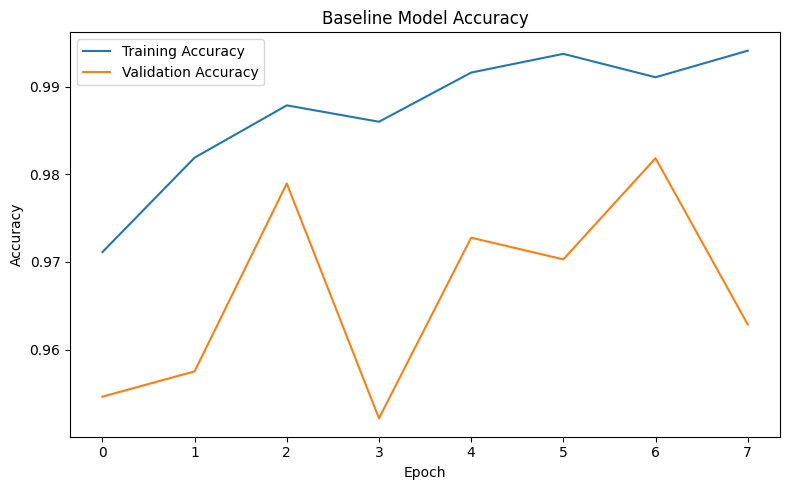

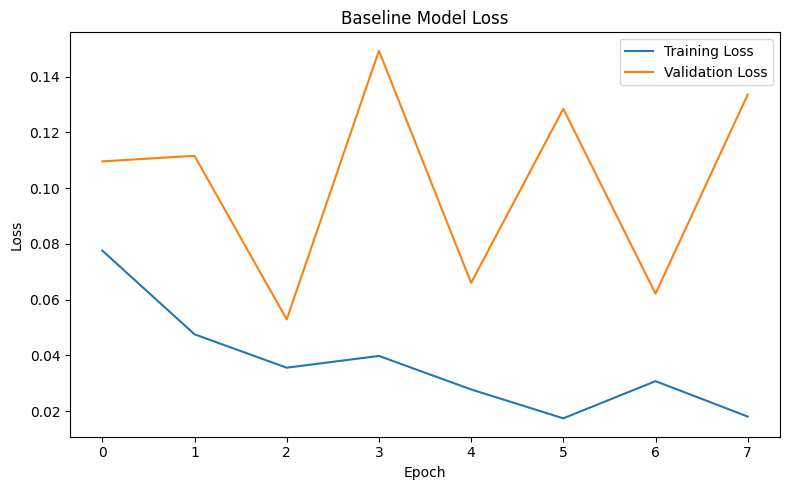

In [70]:
# Plot training and validation accuracy and loss for the baseline model

history_df = pd.DataFrame(baseline_history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Baseline Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Baseline Model Evaluation

In [71]:
# Generate predictions on the validation set and compute evaluation metrics

val_generator.reset()

baseline_pred_probs = baseline_model.predict(val_generator, verbose=1)
baseline_pred_labels = np.argmax(baseline_pred_probs, axis=1)

true_labels = val_generator.classes

class_names = [
    class_name for class_name, index in sorted(
        val_generator.class_indices.items(),
        key=lambda item: item[1]
    )
]

baseline_accuracy = accuracy_score(true_labels, baseline_pred_labels)
baseline_precision = precision_score(true_labels, baseline_pred_labels, average="weighted")
baseline_recall = recall_score(true_labels, baseline_pred_labels, average="weighted")
baseline_f1 = f1_score(true_labels, baseline_pred_labels, average="weighted")

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step
Baseline Accuracy: 0.9790
Baseline Precision: 0.9805
Baseline Recall: 0.9790
Baseline F1-score: 0.9788


In [72]:
# Print the classification report for the baseline model

print("Baseline Classification Report:\n")
print(classification_report(true_labels, baseline_pred_labels, target_names=class_names))

Baseline Classification Report:

              precision    recall  f1-score   support

    Cautions       0.86      0.98      0.92       240
   Crossings       0.97      0.82      0.89       209
   Direction       1.00      1.00      1.00       477
    No Entry       1.00      0.98      0.99       419
  SpeedLimit       0.99      1.00      1.00      1079

    accuracy                           0.98      2424
   macro avg       0.96      0.96      0.96      2424
weighted avg       0.98      0.98      0.98      2424



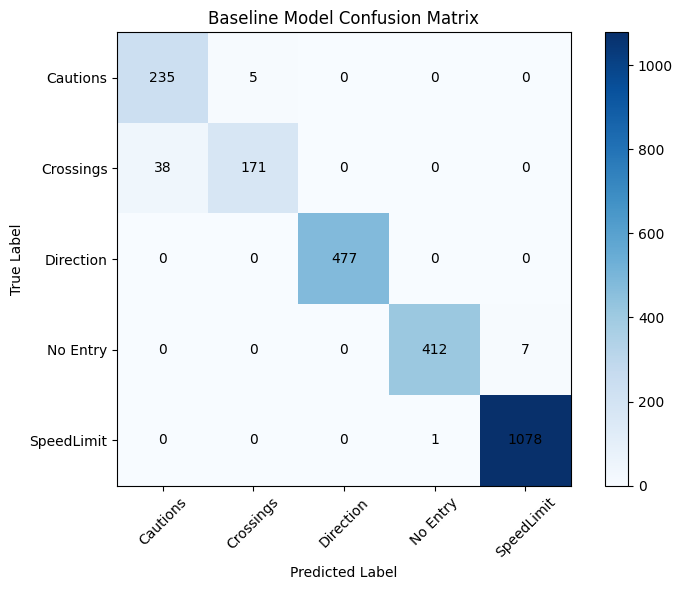

In [73]:
# Plot the confusion matrix for the baseline model

baseline_cm = confusion_matrix(true_labels, baseline_pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(baseline_cm, interpolation="nearest", cmap="Blues")
plt.title("Baseline Model Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(baseline_cm.shape[0]):
    for j in range(baseline_cm.shape[1]):
        plt.text(j, i, baseline_cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 17. Baseline Sample Predictions

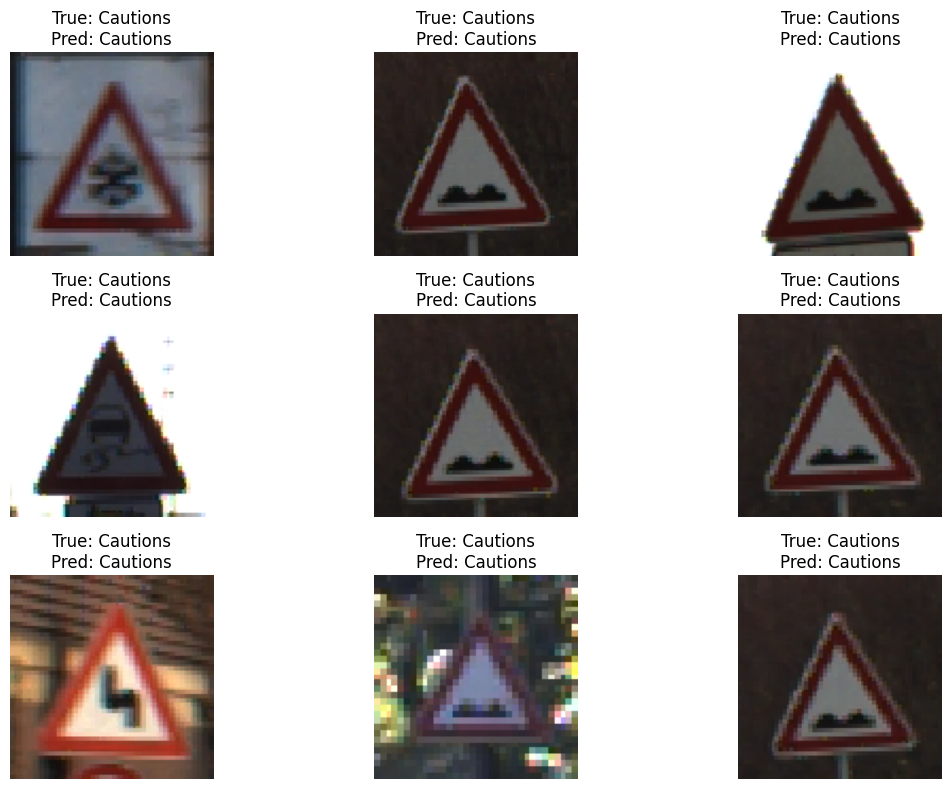

In [74]:
# Display sample validation images with true and predicted labels

sample_batch_images, sample_batch_labels = next(val_generator)

sample_pred_probs = baseline_model.predict(sample_batch_images, verbose=0)
sample_pred_labels = np.argmax(sample_pred_probs, axis=1)
sample_true_labels = np.argmax(sample_batch_labels, axis=1)

class_names = list(val_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)
    plt.imshow(sample_batch_images[index])

    true_label = class_names[sample_true_labels[index]]
    pred_label = class_names[sample_pred_labels[index]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 17. Key Observations about Baseline Model Performance

- The baseline CNN achieved very high validation performance.
- Training and validation accuracy remained very close.
- Validation loss stayed low throughout training.
- This suggests that the model learned the task effectively.
- There was no strong sign of severe overfitting.
- The model made only a few misclassifications on the validation set.
- Overall, the baseline model provided a strong reference for later comparison.

# 2.5.3 Deeper Architecture with Regularization Layer

## 18. Deeper CNN with Regularization

In [75]:
# Build a deeper CNN model with batch normalization and dropout

deeper_model = Sequential([
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),

    layers.Dense(5, activation="softmax")
])

deeper_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,236,805 (4.72 MB)

 Trainable params: 1,235,077 (4.71 MB)

 Non-trainable params: 1,728 (6.75 KB)

## 19. Deeper Model Training

In [77]:
# Train the deeper CNN model

deeper_early_stopping = EarlyStopping(
    monitor="val_loss",      # stop based on validation loss
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True
)

deeper_start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[deeper_early_stopping],
    verbose=1
)

deeper_training_time = time.time() - deeper_start_time

print(f"Deeper model training time: {deeper_training_time:.2f} seconds")

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 217s 618ms/step - accuracy: 0.8998 - loss: 0.2011 - val_accuracy: 0.9105 - val_loss: 0.2361
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 606ms/step - accuracy: 0.9619 - loss: 0.1014 - val_accuracy: 0.9843 - val_loss: 0.0400
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 217s 618ms/step - accuracy: 0.9802 - loss: 0.0600 - val_accuracy: 0.9802 - val_loss: 0.0495
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 215s 612ms/step - accuracy: 0.9906 - loss: 0.0349 - val_accuracy: 0.9785 - val_loss: 0.0579
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 217s 618ms/step - accuracy: 0.9933 - loss: 0.0251 - val_accuracy: 0.9806 - val_loss: 0.0493
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 216s 615ms/step - accuracy: 0.9942 - loss: 0.0232 - val_accuracy: 0.9827 - val_loss: 0.0636
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 608ms/step - accuracy: 0.9953 - loss: 0.0135 - val_accuracy: 0.9864 - val_loss: 0.0519
Deeper model training time: 1508.79 seconds


## 20. Deeper Model Training Curves

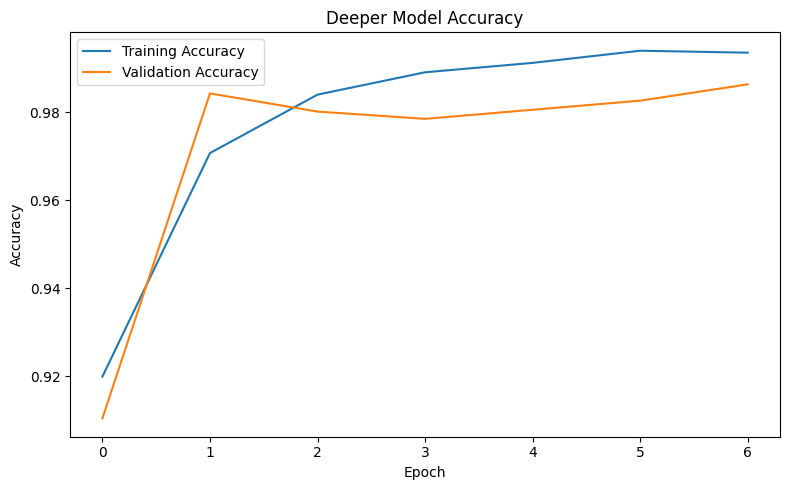

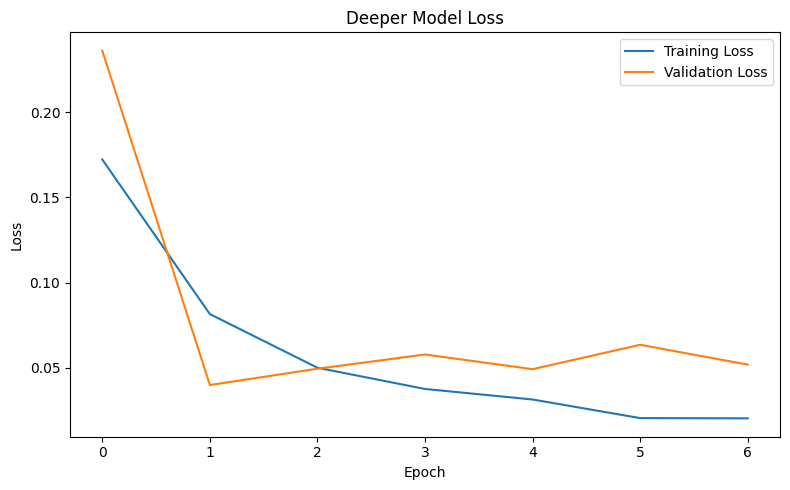

In [78]:
# Plot training and validation accuracy and loss for the deeper model

deeper_history_df = pd.DataFrame(deeper_history.history)

plt.figure(figsize=(8, 5))
plt.plot(deeper_history_df["accuracy"], label="Training Accuracy")
plt.plot(deeper_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Deeper Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(deeper_history_df["loss"], label="Training Loss")
plt.plot(deeper_history_df["val_loss"], label="Validation Loss")
plt.title("Deeper Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Deeper Model Evaluation

In [79]:
# Generate predictions on the validation set and compute evaluation metrics for the deeper model

val_generator.reset()

deeper_pred_probs = deeper_model.predict(val_generator, verbose=1)
deeper_pred_labels = np.argmax(deeper_pred_probs, axis=1)

true_labels = val_generator.classes
class_names = list(val_generator.class_indices.keys())

deeper_accuracy = accuracy_score(true_labels, deeper_pred_labels)
deeper_precision = precision_score(true_labels, deeper_pred_labels, average="weighted")
deeper_recall = recall_score(true_labels, deeper_pred_labels, average="weighted")
deeper_f1 = f1_score(true_labels, deeper_pred_labels, average="weighted")

print(f"Deeper Model Accuracy: {deeper_accuracy:.4f}")
print(f"Deeper Model Precision: {deeper_precision:.4f}")
print(f"Deeper Model Recall: {deeper_recall:.4f}")
print(f"Deeper Model F1-score: {deeper_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step
Deeper Model Accuracy: 0.9843
Deeper Model Precision: 0.9844
Deeper Model Recall: 0.9843
Deeper Model F1-score: 0.9843


In [ ]:
# Print the classification report for the deeper model

print("Deeper Model Classification Report:\n")
print(classification_report(true_labels, deeper_pred_labels, target_names=class_names))

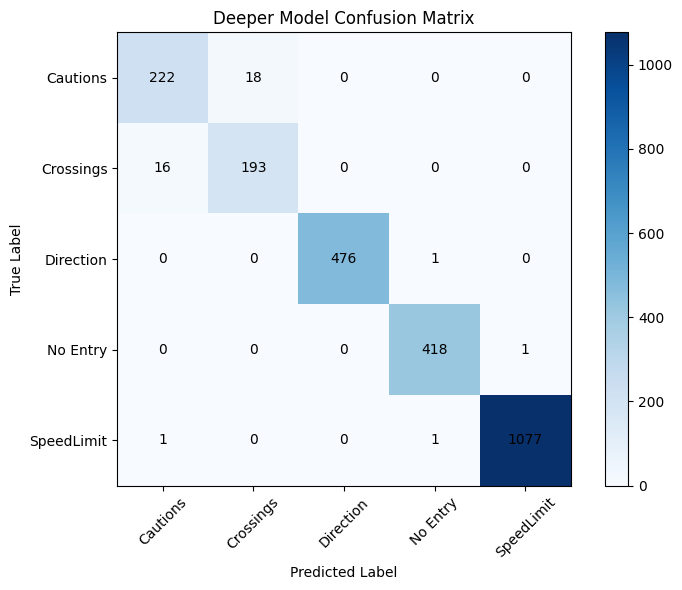

In [80]:
# Plot the confusion matrix for the deeper model

deeper_cm = confusion_matrix(true_labels, deeper_pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(deeper_cm, interpolation="nearest", cmap="Blues")
plt.title("Deeper Model Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(deeper_cm.shape[0]):
    for j in range(deeper_cm.shape[1]):
        plt.text(j, i, deeper_cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

### 21. Deeper Model Evaluation

- The deeper CNN was evaluated using accuracy, precision, recall, and F1-score.
- These were the same metrics used for the baseline model.
- The deeper model performed slightly better than the baseline.
- It also achieved a lower validation loss.
- This suggests that the added layers and regularization improved performance.
- However, the improvement was small because the baseline was already very strong.

# 2.5.4 Experimentation and Comparative Analysis

## 22. Baseline vs Deeper Model Comparison

In [81]:
# Compare the baseline and deeper models using accuracy, loss, evaluation metrics, and training time

baseline_best_val_loss = min(baseline_history.history["val_loss"])
deeper_best_val_loss = min(deeper_history.history["val_loss"])

comparison_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        "Accuracy": baseline_accuracy,
        "Best_Val_Loss": baseline_best_val_loss,
        "Precision": baseline_precision,
        "Recall": baseline_recall,
        "F1-score": baseline_f1,
        "Training_Time_Seconds": baseline_training_time
    },
    {
        "Model": "Deeper CNN",
        "Accuracy": deeper_accuracy,
        "Best_Val_Loss": deeper_best_val_loss,
        "Precision": deeper_precision,
        "Recall": deeper_recall,
        "F1-score": deeper_f1,
        "Training_Time_Seconds": deeper_training_time
    }
]).round(4)

print(comparison_df)

          Model  Accuracy  Best_Val_Loss  Precision  Recall  F1-score  \
0  Baseline CNN    0.9790         0.0529     0.9805  0.9790    0.9788   
1    Deeper CNN    0.9843         0.0400     0.9844  0.9843    0.9843   

   Training_Time_Seconds  
0               882.5674  
1              1508.7936  


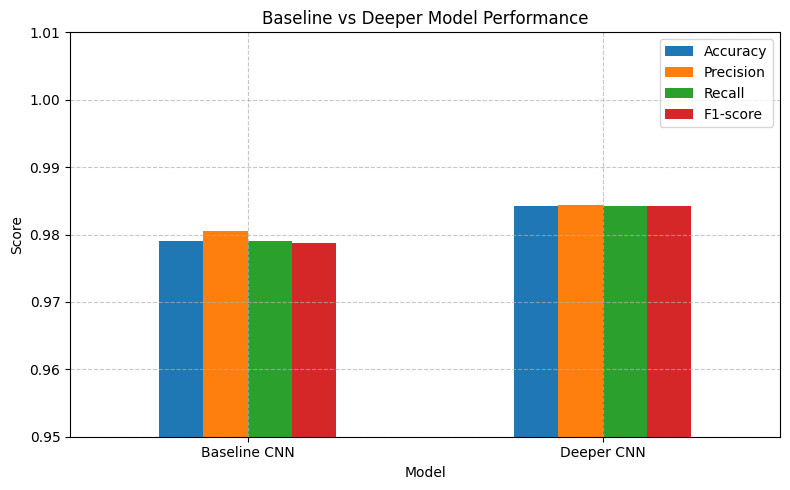

In [82]:
# Plot a simple metric comparison between the baseline and deeper models

metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]

comparison_plot_df = comparison_df.set_index("Model")[metric_names]

ax = comparison_plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Baseline vs Deeper Model Performance")
plt.ylabel("Score")
plt.ylim(0.95, 1.01)
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

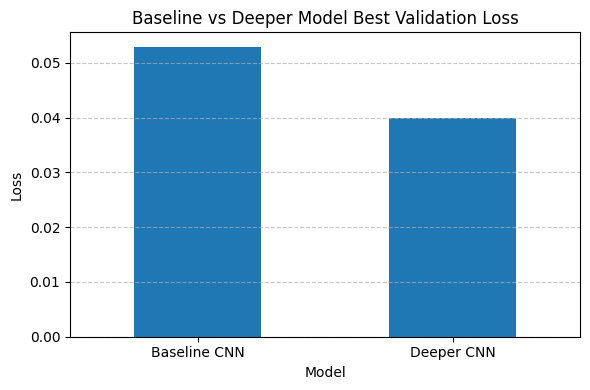

In [83]:
loss_plot_df = comparison_df.set_index("Model")[["Best_Val_Loss"]]

ax = loss_plot_df.plot(kind="bar", figsize=(6, 4), legend=False)
plt.title("Baseline vs Deeper Model Best Validation Loss")
plt.ylabel("Loss")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 22. Computational Efficiency

In [84]:
# Compare training time and parameter count of the baseline and deeper models

baseline_params = baseline_model.count_params()
deeper_params = deeper_model.count_params()

efficiency_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        "Total_Parameters": baseline_params,
        "Training_Time_Seconds": baseline_training_time
    },
    {
        "Model": "Deeper CNN",
        "Total_Parameters": deeper_params,
        "Training_Time_Seconds": deeper_training_time
    }
])

print(efficiency_df)

          Model  Total_Parameters  Training_Time_Seconds
0  Baseline CNN           3411781             882.567426
1    Deeper CNN           1236805            1508.793611


- The baseline CNN was slightly more efficient in training time.
- The deeper CNN was more complex because it used more convolutional layers and regularization.
- This extra complexity slightly improved performance.
- However, it also increased computational effort and training time.
- Therefore, the trade-off is between better feature learning and lower efficiency.


### 23. Optimizer Analysis: SGD vs Adam

In [86]:
# Rebuild the deeper CNN architecture for optimizer comparison

def build_deeper_model(optimizer):
    """
    Build and compile the deeper CNN model for optimizer comparison.

    Parameters:
    optimizer : keras optimizer
        Optimizer used to train the model.

    Returns:
    keras.Model
        Compiled deeper CNN model.
    """
    model = Sequential([
        layers.Input(shape=(96, 96, 3)),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(64, activation="relu"),

        layers.Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [88]:
# Train the deeper CNN using SGD optimizer

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

deeper_model_sgd = build_deeper_model(sgd_optimizer)

sgd_early_stopping = EarlyStopping(
    monitor="val_loss",      # stop based on validation loss
    patience=5,              # wait 5 epochs before stopping
    restore_best_weights=True
)

sgd_start_time = time.time()

sgd_history = deeper_model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[sgd_early_stopping],
    verbose=1
)

sgd_training_time = time.time() - sgd_start_time

print(f"SGD training time: {sgd_training_time:.2f} seconds")

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 221s 619ms/step - accuracy: 0.6117 - loss: 1.0343 - val_accuracy: 0.7719 - val_loss: 0.5685
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 222s 633ms/step - accuracy: 0.8681 - loss: 0.2654 - val_accuracy: 0.8767 - val_loss: 0.2166
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 215s 613ms/step - accuracy: 0.8948 - loss: 0.1881 - val_accuracy: 0.8956 - val_loss: 0.1758
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 214s 611ms/step - accuracy: 0.9488 - loss: 0.1224 - val_accuracy: 0.9559 - val_loss: 0.1105
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 606ms/step - accuracy: 0.9783 - loss: 0.0576 - val_accuracy: 0.9443 - val_loss: 0.2545
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 259s 597ms/step - accuracy: 0.9885 - loss: 0.0370 - val_accuracy: 0.9897 - val_loss: 0.0281
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 212s 604ms/step - accuracy: 0.9919 - loss: 0.0332 - val_accuracy: 0.9641 - val_loss: 0.1094
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 211s 599ms/step - accuracy: 0.9967 -

## 24. SGD Model Evaluation

In [89]:
# Evaluate the deeper CNN trained with SGD

val_generator.reset()

sgd_pred_probs = deeper_model_sgd.predict(val_generator, verbose=1)
sgd_pred_labels = np.argmax(sgd_pred_probs, axis=1)

true_labels = val_generator.classes

sgd_accuracy = accuracy_score(true_labels, sgd_pred_labels)
sgd_precision = precision_score(true_labels, sgd_pred_labels, average="weighted")
sgd_recall = recall_score(true_labels, sgd_pred_labels, average="weighted")
sgd_f1 = f1_score(true_labels, sgd_pred_labels, average="weighted")

print(f"SGD Accuracy: {sgd_accuracy:.4f}")
print(f"SGD Precision: {sgd_precision:.4f}")
print(f"SGD Recall: {sgd_recall:.4f}")
print(f"SGD F1-score: {sgd_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step
SGD Accuracy: 0.9905
SGD Precision: 0.9907
SGD Recall: 0.9905
SGD F1-score: 0.9905


## 25. SGD vs Adam Comparison

In [90]:
# Compare the deeper CNN trained with Adam and SGD

optimizer_comparison_df = pd.DataFrame([
    {
        "Optimizer": "Adam",
        "Accuracy": deeper_accuracy,
        "Precision": deeper_precision,
        "Recall": deeper_recall,
        "F1-score": deeper_f1,
        "Training_Time_Seconds": deeper_training_time
    },
    {
        "Optimizer": "SGD",
        "Accuracy": sgd_accuracy,
        "Precision": sgd_precision,
        "Recall": sgd_recall,
        "F1-score": sgd_f1,
        "Training_Time_Seconds": sgd_training_time
    }
]).round(4)

print(optimizer_comparison_df)

  Optimizer  Accuracy  Precision  Recall  F1-score  Training_Time_Seconds
0      Adam    0.9843     0.9844  0.9843    0.9843              1508.7936
1       SGD    0.9905     0.9907  0.9905    0.9905              3091.0731


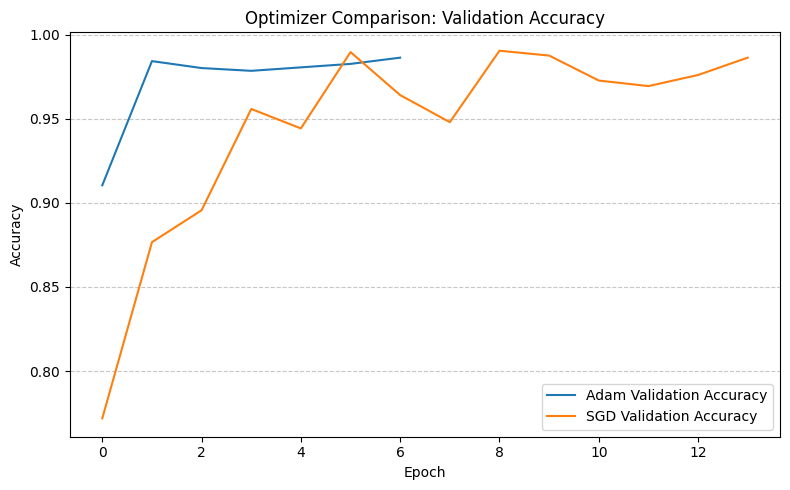

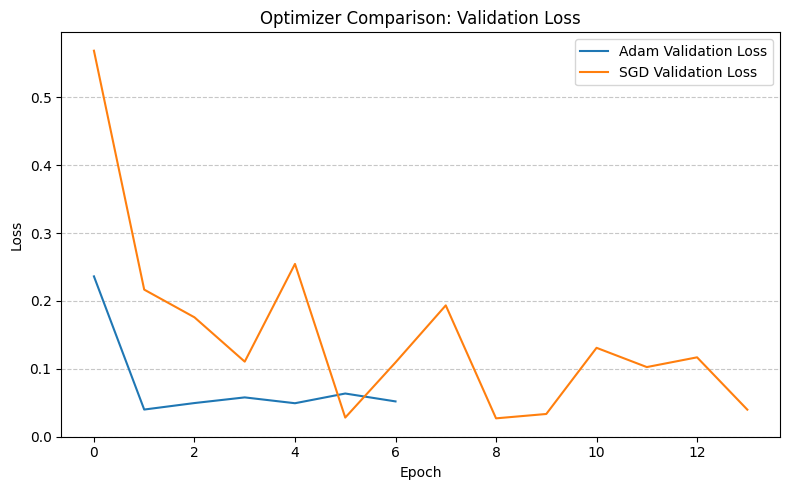

In [91]:
# Plot the validation accuracy and validation loss curves for Adam and SGD

plt.figure(figsize=(8, 5))
plt.plot(deeper_history.history["val_accuracy"], label="Adam Validation Accuracy")
plt.plot(sgd_history.history["val_accuracy"], label="SGD Validation Accuracy")
plt.title("Optimizer Comparison: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(deeper_history.history["val_loss"], label="Adam Validation Loss")
plt.plot(sgd_history.history["val_loss"], label="SGD Validation Loss")
plt.title("Optimizer Comparison: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 26. Ablation Study

In [76]:
# Build the ablation model by removing dropout from the deeper CNN architecture

def build_ablation_model_no_dropout(optimizer):
    """
    Build and compile the deeper CNN model without dropout.

    Parameters:
    optimizer : keras optimizer
        Optimizer used to train the model.

    Returns:
    keras.Model
        Compiled deeper CNN model without dropout.
    """
    model = Sequential([
        layers.Input(shape=(96, 96, 3)),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(256, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(5, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [77]:
# Train the ablation model without dropout using Adam

ablation_model = build_ablation_model_no_dropout(
    keras.optimizers.Adam(learning_rate=0.001)
)

ablation_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

ablation_start_time = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[ablation_early_stopping],
    verbose=1
)

ablation_training_time = time.time() - ablation_start_time

print(f"Ablation model training time: {ablation_training_time:.2f} seconds")

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 113ms/step - accuracy: 0.7368 - loss: 0.6731 - val_accuracy: 0.8894 - val_loss: 0.2453
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.9640 - loss: 0.0984 - val_accuracy: 0.9645 - val_loss: 0.1083
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9868 - loss: 0.0406 - val_accuracy: 0.9678 - val_loss: 0.1173
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9943 - loss: 0.0208 - val_accuracy: 0.9818 - val_loss: 0.0682
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9892 - loss: 0.0305 - val_accuracy: 0.9744 - val_loss: 0.0624
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9949 - loss: 0.0149 - val_accuracy: 0.9101 - val_loss: 0.3425
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.9908 - loss: 0.0293 - val_accuracy: 0.9893 - val_loss: 0.0293
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9947 - loss: 0.0137 - val_accura

## 27. Ablation Model Evaluation

In [78]:
# Evaluate the ablation model on the validation set

val_generator.reset()

ablation_pred_probs = ablation_model.predict(val_generator, verbose=1)
ablation_pred_labels = np.argmax(ablation_pred_probs, axis=1)

true_labels = val_generator.classes

ablation_accuracy = accuracy_score(true_labels, ablation_pred_labels)
ablation_precision = precision_score(true_labels, ablation_pred_labels, average="weighted")
ablation_recall = recall_score(true_labels, ablation_pred_labels, average="weighted")
ablation_f1 = f1_score(true_labels, ablation_pred_labels, average="weighted")

print(f"Ablation Accuracy: {ablation_accuracy:.4f}")
print(f"Ablation Precision: {ablation_precision:.4f}")
print(f"Ablation Recall: {ablation_recall:.4f}")
print(f"Ablation F1-score: {ablation_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
Ablation Accuracy: 0.9955
Ablation Precision: 0.9955
Ablation Recall: 0.9955
Ablation F1-score: 0.9955


## 28. Dropout Ablation Comparison

In [96]:
# Compare the regularized deeper model with the ablation model without dropout

ablation_comparison_df = pd.DataFrame([
    {
        "Model": "Deeper CNN with Dropout",
        "Accuracy": deeper_accuracy,
        "Precision": deeper_precision,
        "Recall": deeper_recall,
        "F1-score": deeper_f1,
        "Training_Time_Seconds": deeper_training_time
    },
    {
        "Model": "Deeper CNN without Dropout",
        "Accuracy": ablation_accuracy,
        "Precision": ablation_precision,
        "Recall": ablation_recall,
        "F1-score": ablation_f1,
        "Training_Time_Seconds": ablation_training_time
    }
]).round(4)

print(ablation_comparison_df)

                        Model  Accuracy  Precision  Recall  F1-score  \
0     Deeper CNN with Dropout    0.9843     0.9844  0.9843    0.9843   
1  Deeper CNN without Dropout    0.9992     0.9992  0.9992    0.9992   

   Training_Time_Seconds  
0              1508.7936  
1              2949.3078  


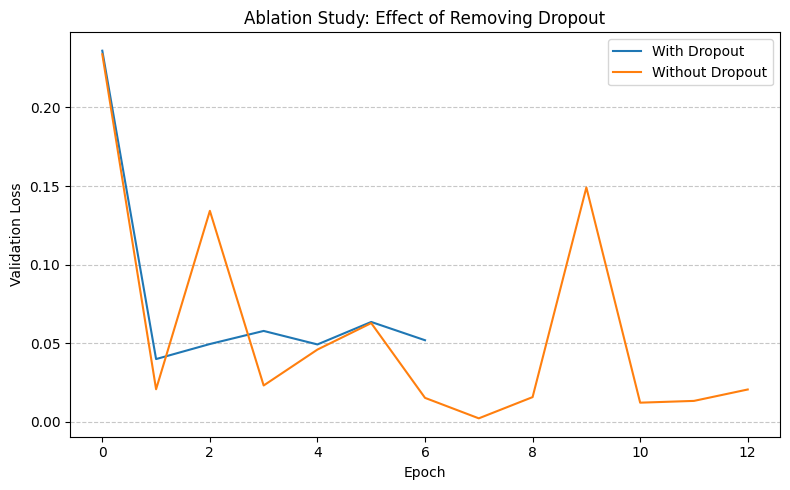

In [97]:
# Plot the validation loss curves to observe the effect of removing dropout

plt.figure(figsize=(8, 5))
plt.plot(deeper_history.history["val_loss"], label="With Dropout")
plt.plot(ablation_history.history["val_loss"], label="Without Dropout")
plt.title("Ablation Study: Effect of Removing Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# 2.5.4 Experimentation and Comparative Analysis
### 29. Challenges and Observations

- The dataset presented quality issues, including low-resolution images, dark samples, and 35 corrupted files that had to be removed.
- Class imbalance was another challenge, because SpeedLimit had many more samples than smaller classes such as Cautions and Crossings.
- Overfitting was a possible risk because both models achieved very high validation performance.
- To reduce this risk, data augmentation, batch normalization, dropout, and early stopping were applied.
- The deeper model showed some fluctuation in validation loss, suggesting that deeper architectures can be less stable during training.
- Google Colab with GPU acceleration was used to make training and repeated experiments more practical.
- The deeper CNN took about 1007.08 seconds with Adam and about 957.15 seconds with SGD.

# 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

# 2.6.1 Pre-Trained Model Selection and Setup

## 30. Pre-Trained Model Selection and Setup

- MobileNetV2 was selected as the pre-trained model.
- It is lighter than larger models such as VGG or ResNet.
- It is suitable for transfer learning with limited training time.
- The input size was changed to 224 × 224 to match the pre-trained model.
- The first stage uses feature extraction by freezing the convolutional base.

In [54]:
# Define cleaned training directory if notebook state was reset

from pathlib import Path

clean_root_dir = Path("/content/traffic_sign_cleaned")
clean_train_dir = clean_root_dir / "Train"

print("Clean train directory:", clean_train_dir)
print("Exists:", clean_train_dir.exists())

Clean train directory: /content/traffic_sign_cleaned/Train
Exists: True


In [46]:
# Create dataframe of cleaned image paths and labels, then split into train/validation/test

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

# Build dataframe from cleaned training directory
image_records = []

for class_folder in sorted([folder for folder in clean_train_dir.iterdir() if folder.is_dir()]):
    class_name = class_folder.name

    for file_path in class_folder.iterdir():
        if file_path.is_file():
            image_records.append(
                {
                    "filepath": str(file_path),
                    "label": class_name
                }
            )

image_df = pd.DataFrame(image_records)

print("Total cleaned image records:", len(image_df))
print(image_df.head())


def make_group_id(filepath, label):
    """
    Create a group ID from an image filepath and its class label.

    Parameters:
        filepath: Full path of the image file.
        label: Class label of the image.

    Returns:
        A group ID based on the class label and first two filename parts.
        This keeps related images in the same split.
    """
    filename = Path(filepath).stem
    parts = filename.split("_")

    # Example: 00004_00002_00011 -> group is 00004_00002
    if len(parts) >= 3:
        group = "_".join(parts[:2])
    else:
        group = filename

    return f"{label}_{group}"


# Add group ID
image_df["group_id"] = image_df.apply(
    lambda row: make_group_id(row["filepath"], row["label"]),
    axis=1
)

# First split: 70% train, 30% temporary
first_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=42
)

train_index, temp_index = next(
    first_split.split(
        image_df,
        groups=image_df["group_id"]
    )
)

train_df = image_df.iloc[train_index].reset_index(drop=True)
temp_df = image_df.iloc[temp_index].reset_index(drop=True)

# Second split: temporary data into 15% validation and 15% test
second_split = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=42
)

val_index, test_index = next(
    second_split.split(
        temp_df,
        groups=temp_df["group_id"]
    )
)

val_df = temp_df.iloc[val_index].reset_index(drop=True)
test_df = temp_df.iloc[test_index].reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

# Group overlap checks
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

print("Train-validation group overlap:", len(train_groups.intersection(val_groups)))
print("Train-test group overlap:", len(train_groups.intersection(test_groups)))
print("Validation-test group overlap:", len(val_groups.intersection(test_groups)))

print("\nTraining split class distribution:")
print(train_df["label"].value_counts())

print("\nValidation split class distribution:")
print(val_df["label"].value_counts())

print("\nTest split class distribution:")
print(test_df["label"].value_counts())

Total cleaned image records: 16065
                                            filepath     label
0  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
1  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
2  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
3  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
4  /content/traffic_sign_cleaned/Train/Cautions/0...  Cautions
Training samples: 11221
Validation samples: 2424
Test samples: 2420
Train-validation group overlap: 0
Train-test group overlap: 0
Validation-test group overlap: 0

Training split class distribution:
label
SpeedLimit    4613
No Entry      2183
Direction     2096
Crossings     1194
Cautions      1135
Name: count, dtype: int64

Validation split class distribution:
label
SpeedLimit    1079
Direction      477
No Entry       419
Cautions       240
Crossings      209
Name: count, dtype: int64

Test split class distribution:
label
SpeedLimit    989
Crossings     418
Direction     388
No E

In [56]:
# Create data generators for transfer learning with MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

transfer_image_size = (224, 224)
transfer_batch_size = 32

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.8, 1.2)
)

transfer_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_train_generator = transfer_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=transfer_image_size,
    class_mode="categorical",
    batch_size=transfer_batch_size,
    shuffle=True,
    seed=random_seed
)

transfer_val_generator = transfer_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=transfer_image_size,
    class_mode="categorical",
    batch_size=transfer_batch_size,
    shuffle=False
)

transfer_test_generator = transfer_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=transfer_image_size,
    class_mode="categorical",
    batch_size=transfer_batch_size,
    shuffle=False
)

Found 11221 validated image filenames belonging to 5 classes.
Found 2424 validated image filenames belonging to 5 classes.
Found 2420 validated image filenames belonging to 5 classes.


In [55]:
# Build the feature-extraction model using a frozen MobileNetV2 base

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow import keras

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False

transfer_model = Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(5, activation="softmax")
])

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 2.6.2 Feature Extraction Training and Evaluation
## 31. Feature Extraction Training

In [57]:
# Train the transfer-learning model with the MobileNetV2 base frozen

transfer_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

transfer_start_time = time.time()

transfer_history = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=15,
    callbacks=[transfer_early_stopping],
    verbose=1
)

transfer_training_time = time.time() - transfer_start_time

print(f"Feature extraction training time: {transfer_training_time:.2f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1778376396.446575     136 service.cc:152] XLA service 0x7a8204002da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778376396.446610     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778376396.446614     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778376397.685373     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 01:26:47.837792: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:26:47.975013: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778376410.302241     136 device_co

100/351 ━━━━━━━━━━━━━━━━━━━━ 1:27 348ms/step - accuracy: 0.7271 - loss: 0.7473

2026-05-10 01:27:33.893075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:27:34.046181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:27:34.183378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8343 - loss: 0.4422

2026-05-10 01:29:18.034542: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 01:29:18.171710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 169s 427ms/step - accuracy: 0.8345 - loss: 0.4416 - val_accuracy: 0.9002 - val_loss: 0.2154
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 354ms/step - accuracy: 0.9596 - loss: 0.1127 - val_accuracy: 0.9101 - val_loss: 0.2000
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 355ms/step - accuracy: 0.9672 - loss: 0.0866 - val_accuracy: 0.9295 - val_loss: 0.1829
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 123s 351ms/step - accuracy: 0.9708 - loss: 0.0742 - val_accuracy: 0.9183 - val_loss: 0.1817
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 123s 350ms/step - accuracy: 0.9757 - loss: 0.0667 - val_accuracy: 0.9154 - val_loss: 0.2003
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 352ms/step - accuracy: 0.9806 - loss: 0.0566 - val_accuracy: 0.9097 - val_loss: 0.2397
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 353ms/step - accuracy: 0.9811 - loss: 0.0548 - val_accuracy: 0.9187 - val_loss: 0.1968
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 356ms/step - accuracy: 0.9823 - loss: 0.04

## 32. Feature Extraction Evaluation

In [58]:
# Evaluate the feature-extraction model on the validation set

transfer_val_generator.reset()

transfer_pred_probs = transfer_model.predict(transfer_val_generator, verbose=1)
transfer_pred_labels = np.argmax(transfer_pred_probs, axis=1)

transfer_true_labels = transfer_val_generator.classes
transfer_class_names = list(transfer_val_generator.class_indices.keys())

transfer_accuracy = accuracy_score(transfer_true_labels, transfer_pred_labels)
transfer_precision = precision_score(transfer_true_labels, transfer_pred_labels, average="weighted")
transfer_recall = recall_score(transfer_true_labels, transfer_pred_labels, average="weighted")
transfer_f1 = f1_score(transfer_true_labels, transfer_pred_labels, average="weighted")

print(f"Feature Extraction Accuracy: {transfer_accuracy:.4f}")
print(f"Feature Extraction Precision: {transfer_precision:.4f}")
print(f"Feature Extraction Recall: {transfer_recall:.4f}")
print(f"Feature Extraction F1-score: {transfer_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step
Feature Extraction Accuracy: 0.9183
Feature Extraction Precision: 0.9197
Feature Extraction Recall: 0.9183
Feature Extraction F1-score: 0.9185


In [59]:
# Print the classification report for the feature-extraction model

print("Feature Extraction Classification Report:\n")
print(classification_report(transfer_true_labels, transfer_pred_labels, target_names=transfer_class_names))

Feature Extraction Classification Report:

              precision    recall  f1-score   support

    Cautions       0.73      0.66      0.69       240
   Crossings       0.66      0.75      0.70       209
   Direction       0.98      0.96      0.97       477
    No Entry       0.95      0.95      0.95       419
  SpeedLimit       0.98      0.98      0.98      1079

    accuracy                           0.92      2424
   macro avg       0.86      0.86      0.86      2424
weighted avg       0.92      0.92      0.92      2424



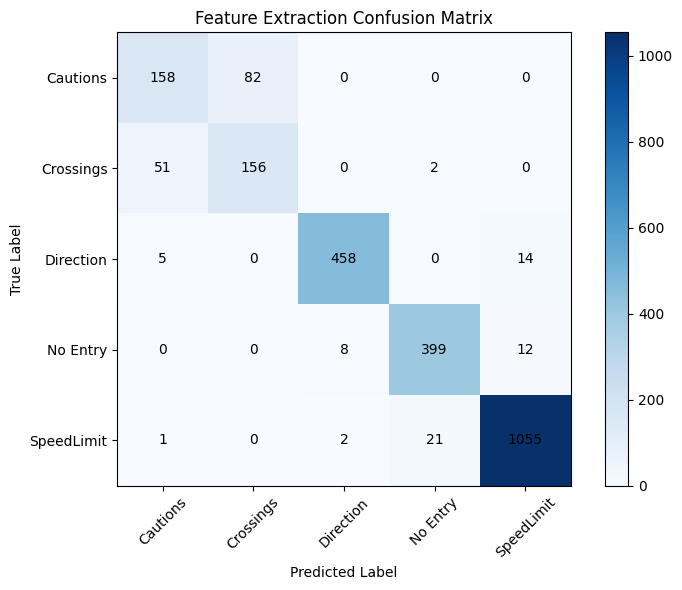

In [60]:
# Plot the confusion matrix for the feature-extraction model

transfer_cm = confusion_matrix(transfer_true_labels, transfer_pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(transfer_cm, interpolation="nearest", cmap="Blues")
plt.title("Feature Extraction Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(transfer_class_names)), transfer_class_names, rotation=45)
plt.yticks(range(len(transfer_class_names)), transfer_class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(transfer_cm.shape[0]):
    for j in range(transfer_cm.shape[1]):
        plt.text(j, i, transfer_cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 33. Feature Extraction Sample Predictions

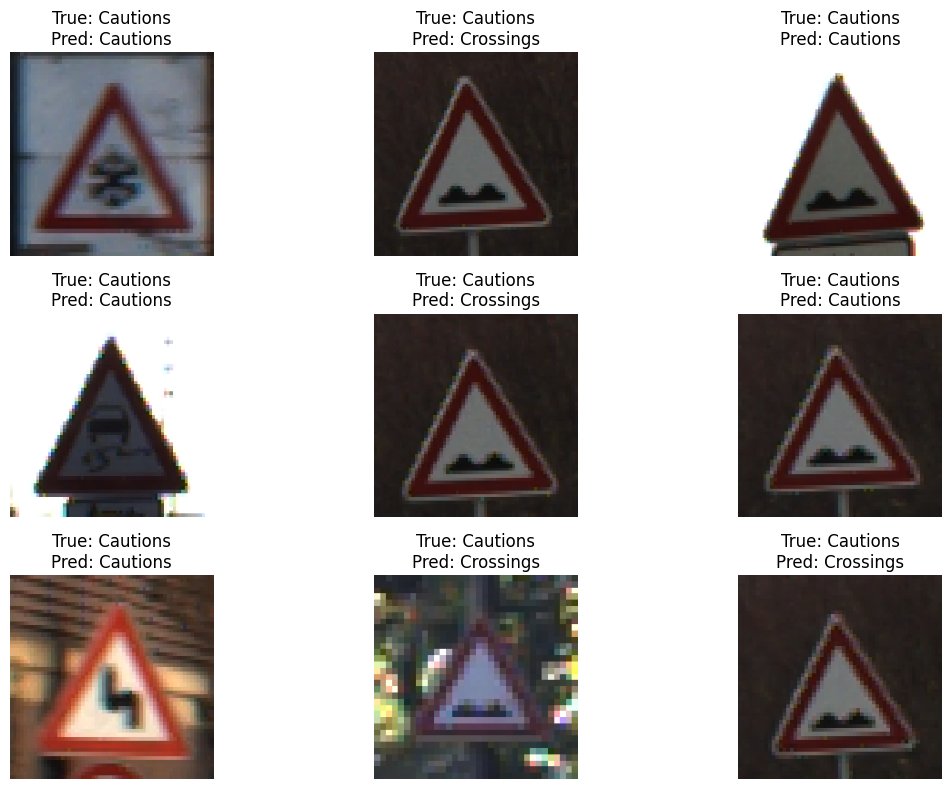

In [61]:
# Display sample validation images with true and predicted labels for the feature-extraction model

sample_transfer_images, sample_transfer_labels = next(transfer_val_generator)

sample_transfer_pred_probs = transfer_model.predict(sample_transfer_images, verbose=0)
sample_transfer_pred_labels = np.argmax(sample_transfer_pred_probs, axis=1)
sample_transfer_true_labels = np.argmax(sample_transfer_labels, axis=1)

transfer_class_names = list(transfer_val_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    display_image = (sample_transfer_images[index] + 1.0) / 2.0
    display_image = np.clip(display_image, 0, 1)

    plt.imshow(display_image)

    true_label = transfer_class_names[sample_transfer_true_labels[index]]
    pred_label = transfer_class_names[sample_transfer_pred_labels[index]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 34. Key Observations about Feature Extraction Performance

- The feature extraction model performed strongly overall.
- Direction and SpeedLimit were classified very well.
- More errors appeared in Cautions and Crossings.
- The confusion matrix supports the classification report.
- Fine-tuning may improve adaptation to this dataset.

# 2.6.3 Fine-Tuning, Prediction, and Final Comparison

## 35. Fine-Tuning Setup

In [64]:
# Fine-tune the upper layers of MobileNetV2

mobilenet_base.trainable = True

# Keep most of the pre-trained base frozen
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stable fine-tuning
for layer in mobilenet_base.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 1,675,333 (6.39 MB)

 Non-trainable params: 747,264 (2.85 MB)

## 36. Fine-Tuning Training

In [65]:
# Fine-tune the transfer-learning model with a low learning rate

fine_tune_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_start_time = time.time()

fine_tune_history = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=10,
    callbacks=[fine_tune_early_stopping],
    verbose=1
)

fine_tune_training_time = time.time() - fine_tune_start_time

print(f"Fine-tuning training time: {fine_tune_training_time:.2f} seconds")

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 147s 388ms/step - accuracy: 0.9951 - loss: 0.0141 - val_accuracy: 0.9476 - val_loss: 0.1639
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 125s 355ms/step - accuracy: 0.9980 - loss: 0.0073 - val_accuracy: 0.9513 - val_loss: 0.1603
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 352ms/step - accuracy: 0.9965 - loss: 0.0106 - val_accuracy: 0.9530 - val_loss: 0.1638
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 353ms/step - accuracy: 0.9982 - loss: 0.0061 - val_accuracy: 0.9641 - val_loss: 0.1126
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 354ms/step - accuracy: 0.9992 - loss: 0.0045 - val_accuracy: 0.9658 - val_loss: 0.1143
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 129s 367ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9645 - val_loss: 0.1378
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 358ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9637 - val_loss: 0.1456
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 124s 354ms/step - accuracy: 0.9990 -

## 37. Fine-Tuned Model Evaluation

In [66]:
# Evaluate the fine-tuned transfer-learning model on the validation set

transfer_val_generator.reset()

fine_tune_pred_probs = transfer_model.predict(transfer_val_generator, verbose=1)
fine_tune_pred_labels = np.argmax(fine_tune_pred_probs, axis=1)

fine_tune_true_labels = transfer_val_generator.classes
fine_tune_class_names = list(transfer_val_generator.class_indices.keys())

fine_tune_accuracy = accuracy_score(fine_tune_true_labels, fine_tune_pred_labels)
fine_tune_precision = precision_score(fine_tune_true_labels, fine_tune_pred_labels, average="weighted")
fine_tune_recall = recall_score(fine_tune_true_labels, fine_tune_pred_labels, average="weighted")
fine_tune_f1 = f1_score(fine_tune_true_labels, fine_tune_pred_labels, average="weighted")

print(f"Fine-Tuned Accuracy: {fine_tune_accuracy:.4f}")
print(f"Fine-Tuned Precision: {fine_tune_precision:.4f}")
print(f"Fine-Tuned Recall: {fine_tune_recall:.4f}")
print(f"Fine-Tuned F1-score: {fine_tune_f1:.4f}")

76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step
Fine-Tuned Accuracy: 0.9641
Fine-Tuned Precision: 0.9645
Fine-Tuned Recall: 0.9641
Fine-Tuned F1-score: 0.9641


In [68]:
# Print the classification report for the fine-tuned model

print("Fine-Tuned Model Classification Report:\n")
print(classification_report(fine_tune_true_labels, fine_tune_pred_labels, target_names=fine_tune_class_names))

Fine-Tuned Model Classification Report:

              precision    recall  f1-score   support

    Cautions       0.86      0.90      0.88       240
   Crossings       0.89      0.83      0.86       209
   Direction       1.00      0.97      0.98       477
    No Entry       0.97      1.00      0.98       419
  SpeedLimit       0.99      0.99      0.99      1079

    accuracy                           0.96      2424
   macro avg       0.94      0.94      0.94      2424
weighted avg       0.96      0.96      0.96      2424



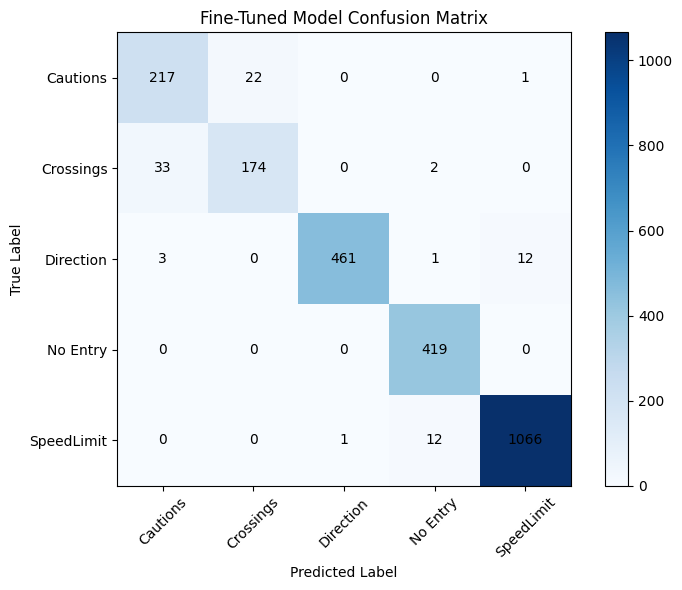

In [69]:
# Plot the confusion matrix for the fine-tuned model

fine_tune_cm = confusion_matrix(fine_tune_true_labels, fine_tune_pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(fine_tune_cm, interpolation="nearest", cmap="Blues")
plt.title("Fine-Tuned Model Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(fine_tune_class_names)), fine_tune_class_names, rotation=45)
plt.yticks(range(len(fine_tune_class_names)), fine_tune_class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(fine_tune_cm.shape[0]):
    for j in range(fine_tune_cm.shape[1]):
        plt.text(j, i, fine_tune_cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 38. Fine-Tuned Model Sample Predictions

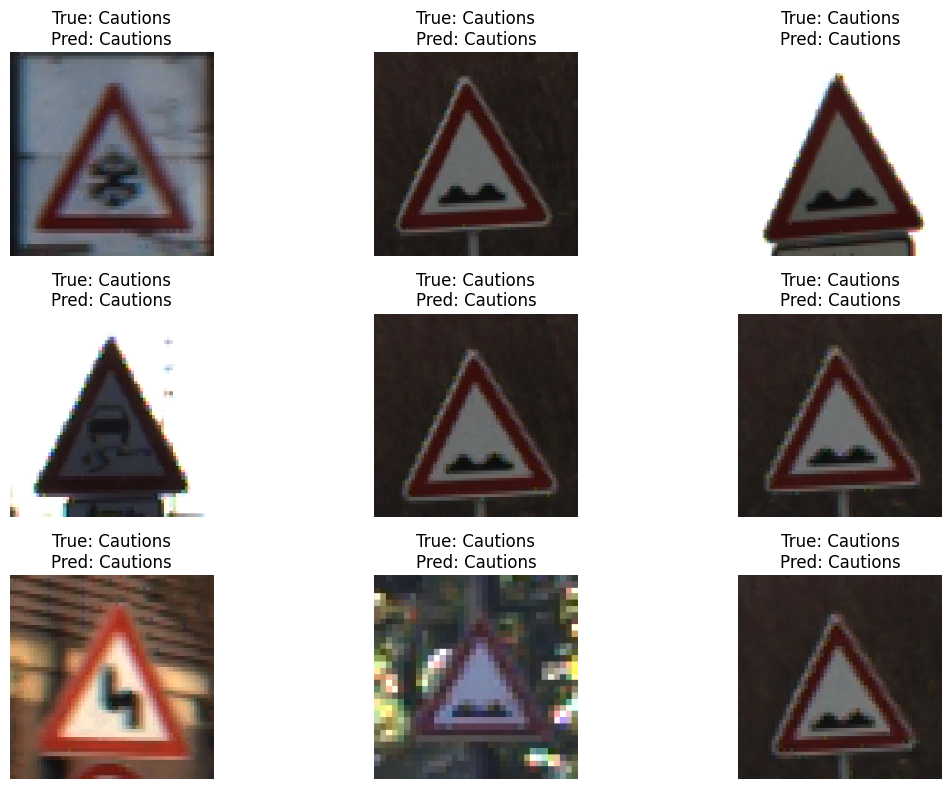

In [70]:
# Predict labels for a validation batch and display them with the true labels

sample_fine_tune_images, sample_fine_tune_labels = next(transfer_val_generator)

sample_fine_tune_pred_probs = transfer_model.predict(sample_fine_tune_images, verbose=0)
sample_fine_tune_pred_labels = np.argmax(sample_fine_tune_pred_probs, axis=1)
sample_fine_tune_true_labels = np.argmax(sample_fine_tune_labels, axis=1)

fine_tune_class_names = list(transfer_val_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    display_image = (sample_fine_tune_images[index] + 1.0) / 2.0
    display_image = np.clip(display_image, 0, 1)

    true_label = fine_tune_class_names[sample_fine_tune_true_labels[index]]
    pred_label = fine_tune_class_names[sample_fine_tune_pred_labels[index]]

    plt.imshow(display_image)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 39. Validation Performance Comparison and Model Selection

In [72]:
# Validation performance comparison across all main models
# Values are from the completed validation evaluations in this notebook run.

final_comparison_df = pd.DataFrame([
    {
        "Model": "Baseline CNN",
        "Accuracy": 0.9790,
        "Precision": 0.9805,
        "Recall": 0.9790,
        "F1-score": 0.9788,
        "Best_Val_Loss": 0.0529,
        "Training_Time_Seconds": 882.5674
    },
    {
        "Model": "Deeper CNN with Dropout (Adam)",
        "Accuracy": 0.9843,
        "Precision": 0.9844,
        "Recall": 0.9843,
        "F1-score": 0.9843,
        "Best_Val_Loss": 0.0400,
        "Training_Time_Seconds": 1508.7936
    },
    {
        "Model": "Deeper CNN with Dropout (SGD)",
        "Accuracy": 0.9905,
        "Precision": 0.9907,
        "Recall": 0.9905,
        "F1-score": 0.9905,
        "Best_Val_Loss": None,
        "Training_Time_Seconds": 3091.0731
    },
    {
        "Model": "Deeper CNN without Dropout",
        "Accuracy": 0.9992,
        "Precision": 0.9992,
        "Recall": 0.9992,
        "F1-score": 0.9992,
        "Best_Val_Loss": None,
        "Training_Time_Seconds": 2949.3078
    },
    {
        "Model": "MobileNetV2 Feature Extraction",
        "Accuracy": 0.9183,
        "Precision": 0.9197,
        "Recall": 0.9183,
        "F1-score": 0.9185,
        "Best_Val_Loss": 0.1817,
        "Training_Time_Seconds": 1161.44
    },
    {
        "Model": "Fine-Tuned MobileNetV2",
        "Accuracy": 0.9641,
        "Precision": 0.9645,
        "Recall": 0.9641,
        "F1-score": 0.9641,
        "Best_Val_Loss": 0.1126,
        "Training_Time_Seconds": 1148.62
    }
])

final_comparison_df = final_comparison_df.round(4)

print(final_comparison_df)

                            Model  Accuracy  Precision  Recall  F1-score  \
0                    Baseline CNN    0.9790     0.9805  0.9790    0.9788   
1  Deeper CNN with Dropout (Adam)    0.9843     0.9844  0.9843    0.9843   
2   Deeper CNN with Dropout (SGD)    0.9905     0.9907  0.9905    0.9905   
3      Deeper CNN without Dropout    0.9992     0.9992  0.9992    0.9992   
4  MobileNetV2 Feature Extraction    0.9183     0.9197  0.9183    0.9185   
5          Fine-Tuned MobileNetV2    0.9641     0.9645  0.9641    0.9641   

   Best_Val_Loss  Training_Time_Seconds  
0         0.0529               882.5674  
1         0.0400              1508.7936  
2            NaN              3091.0731  
3            NaN              2949.3078  
4         0.1817              1161.4400  
5         0.1126              1148.6200  


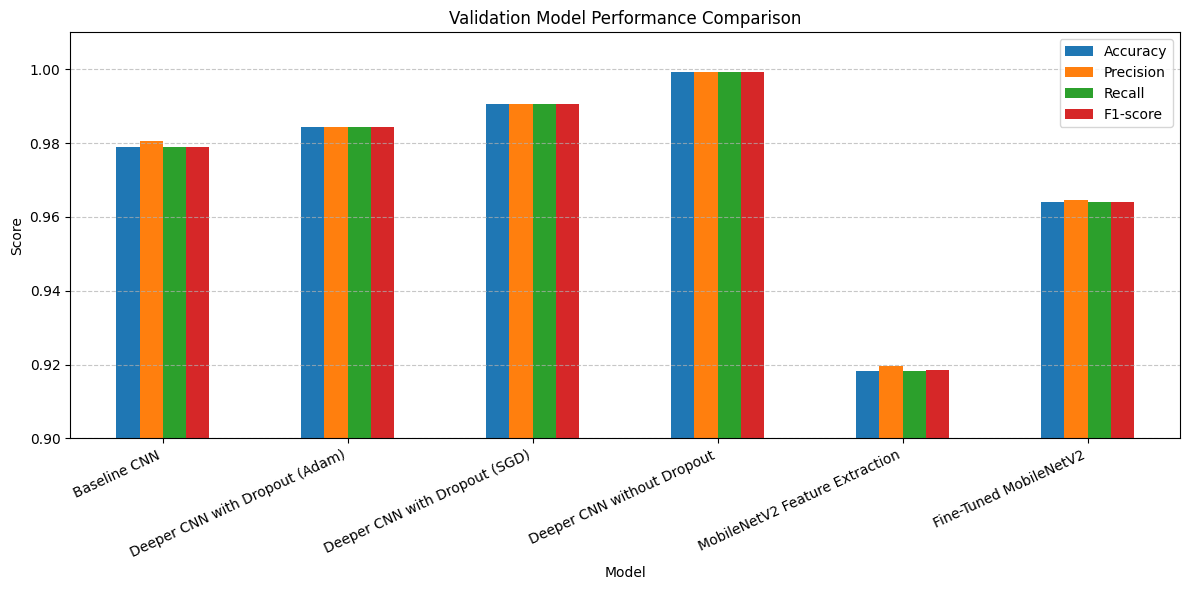

In [86]:
# Plot validation model metric comparison

metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]

validation_metric_df = final_comparison_df.set_index("Model")[metric_names]

ax = validation_metric_df.plot(kind="bar", figsize=(12, 6))

plt.title("Validation Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0.90, 1.01)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

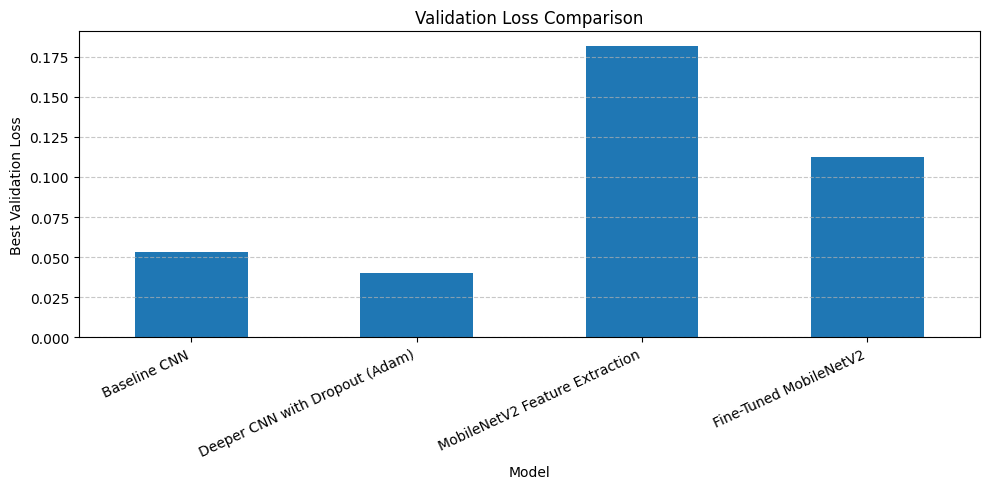

In [87]:
# Plot validation loss comparison

loss_df = final_comparison_df.dropna(subset=["Best_Val_Loss"]).set_index("Model")[["Best_Val_Loss"]]

ax = loss_df.plot(kind="bar", figsize=(10, 5), legend=False)

plt.title("Validation Loss Comparison")
plt.ylabel("Best Validation Loss")
plt.xlabel("Model")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### 40. Key Observations from Validation Model Comparison

- The deeper CNN without dropout achieved the strongest validation performance.
- It had the highest validation accuracy and weighted F1-score.
- The SGD-optimised deeper CNN performed better than the Adam deeper CNN, but required longer training time.
- Fine-tuning improved MobileNetV2 compared with frozen feature extraction.
- The fine-tuned MobileNetV2 performed better than the frozen MobileNetV2 model, but still remained below the custom CNN models.
- Feature extraction was useful as a transfer-learning baseline, but freezing the base limited adaptation to this dataset.
- The transfer-learning models took longer to train because they used larger **224 × 224** input images.
- The deeper CNN without dropout was selected for final testing because it achieved the best validation performance.
- The held-out test set was not used during model selection.

## 41. Final Test Evaluation of Selected Model

In [79]:
# Final test evaluation of the selected best model

test_generator.reset()

test_pred_probs = ablation_model.predict(test_generator, verbose=1)
test_pred_labels = np.argmax(test_pred_probs, axis=1)

test_true_labels = test_generator.classes
test_class_names = list(test_generator.class_indices.keys())

test_accuracy = accuracy_score(test_true_labels, test_pred_labels)
test_precision = precision_score(test_true_labels, test_pred_labels, average="weighted")
test_recall = recall_score(test_true_labels, test_pred_labels, average="weighted")
test_f1 = f1_score(test_true_labels, test_pred_labels, average="weighted")

print(f"Selected Model Test Accuracy: {test_accuracy:.4f}")
print(f"Selected Model Test Precision: {test_precision:.4f}")
print(f"Selected Model Test Recall: {test_recall:.4f}")
print(f"Selected Model Test F1-score: {test_f1:.4f}")

print("\nSelected Model Test Classification Report:\n")
print(classification_report(test_true_labels, test_pred_labels, target_names=test_class_names))

 5/76 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Selected Model Test Accuracy: 0.9864
Selected Model Test Precision: 0.9868
Selected Model Test Recall: 0.9864
Selected Model Test F1-score: 0.9864

Selected Model Test Classification Report:

              precision    recall  f1-score   support

    Cautions       0.92      0.97      0.95       296
   Crossings       0.98      0.94      0.96       418
   Direction       1.00      1.00      1.00       388
    No Entry       1.00      1.00      1.00       329
  SpeedLimit       1.00      1.00      1.00       989

    accuracy                           0.99      2420
   macro avg       0.98      0.98      0.98      2420
weighted avg       0.99      0.99      0.99      2420



In [81]:
# Final test performance table for the selected model

final_test_df = pd.DataFrame([
    {
        "Selected_Model": "Deeper CNN without Dropout",
        "Test_Accuracy": test_accuracy,
        "Test_Precision": test_precision,
        "Test_Recall": test_recall,
        "Test_F1-score": test_f1
    }
]).round(4)

print(final_test_df)

               Selected_Model  Test_Accuracy  Test_Precision  Test_Recall  \
0  Deeper CNN without Dropout         0.9864          0.9868       0.9864   

   Test_F1-score  
0         0.9864  


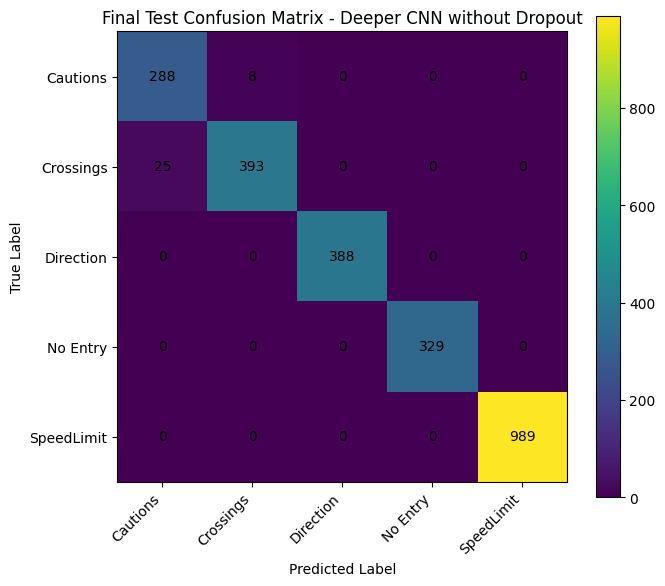

In [82]:
# Plot confusion matrix for the selected model on the test set

test_cm = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(7, 6))
plt.imshow(test_cm)
plt.title("Final Test Confusion Matrix - Deeper CNN without Dropout")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=np.arange(len(test_class_names)),
    labels=test_class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(test_class_names)),
    labels=test_class_names
)

for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        plt.text(j, i, test_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

## 42. Final Test Observation

- The selected deeper CNN without dropout achieved a test accuracy of **0.9864** and a weighted F1-score of **0.9864**.
- The model performed perfectly on **Direction**, **No Entry**, and **SpeedLimit**.
- Most remaining errors were in **Cautions** and **Crossings**, which appear harder to separate than the other classes.
- The final test result is slightly lower than the validation result, which is expected because the test set was held out and not used during model selection.
- Overall, the selected model generalised well to unseen test images.